# 動作の概要


1.  調査したい内容を自然言語で入力
*   文章で記述（英語）
*   論文Abstractのコピペ引用も可
*   年代範囲を指定
*   OpenAI API で Web of Science 用検索クエリ生成
2.  Web of Science（Starter API）で検索を実行
*   文献数（limit=50 WoS API の制約）
3.  検索結果を可視化
*   共著ネットワーク図
*   各nodeは個々の論文、nodeサイズは被引用数
*   共著者でクラスタリング（Louvain）、色分け
*   pyvis形式HTML出力（ダウンロードしてインタラクティブ操作）
*   gexfファイル出力（ダウンロードしてGephi等で可視化）
4.  概要レポート出力（自然言語）
*   最も影響力のある研究者リスト
*   重要な論文トップ3
*   年代ごとの研究トレンド




#Web of Science Starter API で取得できる情報
*   タイトル
*   著者
*   発行年
*   DOI
*   被引用情報
*   など
*   URL,Abstract は Startrer API では直接には取得できない









#API Key の入手
1.   OpenAI
*   下記の記事が参考になる
*   https://qiita.com/kurata04/items/a10bdc44cc0d1e62dad3
2.   Clarivate
*   以下のリンクよりアカウント登録を行う
*    https://developer.clarivate.com/applications?page=1
*   その後、希望のAPIをクリックし、Subscribe を選択すると登録が完了する
*   Clarivateから、ApiKey と endpoint のURLがメールで送られてくる
*   参考：下記にAPIの種類と取得できる情報が掲載されている
*    https://developer.clarivate.com/apis
*   注意）ENDPOINTは末尾が https://･･･/documents になるので注意


3.   API-key は他人に明かさないこと
*   クラウド等への upload も注意
*   漏洩が発覚すると使用停止の可能性あり
*   下記の実行時には、メモ帳等にAPI-keyを保存しておき、コピペで入力する









# Step 1:必要ライブラリをインストール、API Key 入力

In [1]:
pip install openai requests scikit-learn networkx python-louvain matplotlib mplcursors lxml tqdm mpld3 pyvis


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.0 MB/s eta 0:00:00


In [2]:
import getpass
import requests
import json
import time
import re
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import mpld3
from tqdm import tqdm

from openai import OpenAI
import community.community_louvain as community_louvain
import networkx as nx
from pyvis.network import Network

plt.rcParams["font.family"] = "sans-serif"  # 日本語フォントは環境に応じて調整してください


In [3]:
# ---- API キー等の入力 ----
OPENAI_API_KEY = getpass.getpass("Enter your OpenAI API Key: ")
WOS_API_KEY    = getpass.getpass("Enter your Web of Science Starter API Key: ")
#WOS_ENDPOINT   = getpass.getpass("Enter your WoS Endpoint URL (e.g. https://api.clarivate.com/apis/wos-starter/v1/documents): ")
WOS_ENDPOINT   = "https://api.clarivate.com/apis/wos-starter/v2/documents"

client = OpenAI(api_key=OPENAI_API_KEY)


Enter your OpenAI API Key: ··········
Enter your Web of Science Starter API Key: ··········


#Step 2:LLMで WoS クエリに変換

In [4]:
# ============================================================
# Step 2: 自然言語クエリ → WoS query 生成
#   - 利用者に検索内容（自然文 or abstract 全文）を入力させる
#   - 検索期間 (years) を明示的に入力させる
# ============================================================

# 検索内容を入力（自然言語 or abstract）
user_query = input("Describe your research topic or paste from an abstract, etc: ").strip()
print("User Query:", user_query)

# 年代の入力: 例) 1990-2020, 1990 2020 など
years_raw = getpass.getpass("Enter target years from XXXX to YYYY (e.g. 1990-2020): ")
years = re.findall(r'\d{4}', years_raw)
if len(years) >= 2:
    start_year, end_year = years[0], years[1]
    py_clause = f"PY=({start_year}-{end_year})"
else:
    start_year = end_year = None
    py_clause = ""
print(f"Target Years: {start_year} - {end_year}")


def fallback_generate_wos_query(uq: str, py_clause: str = "") -> str:
    """
    OpenAI からの応答が変だったときに使う簡易版の WoS クエリ生成。
    """
    q = uq.lower()
    parts = []

    # テーマが読み取れそうなら、ある程度手書きルールで
    if ("emotion" in q or "affect" in q) and ("pictur" in q or "image" in q or "visual" in q):
        emo = 'TS=(emotion* OR affect* OR "emotional response" OR "emotional responses")'
        pict = 'TS=(pictorial OR picture* OR image* OR "visual stimulus" OR "pictorial stimulus" OR "picture stimuli")'
        parts.append(f"{emo} AND {pict}")
    else:
        # 5文字以上の単語を TS 検索に
        words = [w for w in re.split(r"[^a-zA-Z0-9]+", q) if len(w) > 4]
        if words:
            ts_part = " OR ".join([f"{w}*" for w in words])
            parts.append(f"TS=({ts_part})")
        else:
            parts.append("TS=(general*)")

    if py_clause:
        parts.append(py_clause)

    return " AND ".join(parts)


def natural_to_wos_query(user_query: str,
                         py_clause: str,
                         client,
                         model: str = "gpt-4o-mini",
                         debug_print: bool = True) -> str:
    """
    自然文のリクエスト（or abstract）を WoS Advanced Search 用の query (q) に変換。
    - Topic search (TS=...) を中心に
    - 年代指定は py_clause で付与 (PY=...)
    """
    uq = user_query.strip()

    # { ... } で囲っている場合は中身だけ抜き出す（過去チャット互換）
    if uq.startswith("{") and uq.endswith("}"):
        inner = uq[1:-1].strip()
        if (inner.startswith('"') and inner.endswith('"')) or (inner.startswith("'") and inner.endswith("'")):
            inner = inner[1:-1]
        uq = inner

    # OpenAI に投げるプロンプト
    # 年代条件は必ずクエリに含めるよう指示
    years_hint = f" Also restrict the search to years with the clause `{py_clause}`." if py_clause else ""

    prompt = f"""
You are converting a natural language research request (or a full abstract) to a Web of Science advanced search query.

- Use ONLY the supported field tags for Web of Science Starter API (e.g., TS, TI, AU, SO, PY, etc.).
- Use a topic search (TS=...) to express the main idea.
- Combine terms with Boolean operators AND / OR.
- If appropriate, use wildcards (e.g., emotion*).
- Return exactly ONE valid WoS query for the Starter API, no explanation.{years_hint}

Request:
{uq}
"""

    wos_query = ""
    try:
        resp = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "Output a single Web of Science advanced search query usable by the WoS Starter API. No explanation."},
                {"role": "user",   "content": prompt},
            ],
            max_tokens=256,
            temperature=0.0,
        )
        wos_query = resp.choices[0].message.content.strip()
    except Exception as e:
        print("LLM query generation failed, using fallback:", e)
        wos_query = ""

    # 念のため、PY が含まれていない場合は py_clause を付け足す
    if py_clause and ("PY=" not in wos_query):
        if wos_query:
            wos_query = f"({wos_query}) AND {py_clause}"
        else:
            wos_query = py_clause

    # それでも短すぎたりおかしそうなら fallback
    if (not wos_query) or (len(wos_query) < 10):
        if debug_print:
            print("[Fallback used for WoS query generation]")
        wos_query = fallback_generate_wos_query(uq, py_clause=py_clause)

    if debug_print:
        print("\n=== WoS Query Generated ===")
        print(wos_query)
        print("===========================\n")

    return wos_query


# 実行
wos_query = natural_to_wos_query(user_query, py_clause, client)


Describe your research topic or paste from an abstract, etc: We trained a large, deep convolutional neural network to classify the 1.2 million high-resolution images in the ImageNet LSVRC-2010 contest into the 1000 different classes. On the test data, we achieved top-1 and top-5 error rates of 37.5% and 17.0%, respectively, which is considerably better than the previous state-of-the-art. The neural network, which has 60 million parameters and 650,000 neurons, consists of five convolutional layers, some of which are followed by max-pooling layers, and three fully connected layers with a final 1000-way softmax. To make training faster, we used non-saturating neurons and a very efficient GPU implementation of the convolution operation. To reduce overfitting in the fully connected layers we employed a recently developed regularization method called “dropout” that proved to be very effective. We also entered a variant of this model in the ILSVRC-2012 competition and achieved a winning top-5

#Step 3:WoS API検索

In [5]:
# ============================================================
# Step 3: WoS Starter API 検索
#   - q = wos_query
#   - limit = 50
#   - times cited 降順（できれば sortField=TC+D を使用）
#   - 簡単なリトライ & バックオフ
# ============================================================

headers = {"X-ApiKey": WOS_API_KEY.strip()}
BASE_URL = WOS_ENDPOINT.strip()  # 通常は .../documents を指す


def call_wos_documents(q,
                       db="WOS",
                       limit=50,
                       page=1,
                       max_retries=5,
                       initial_backoff=1.0):
    """
    WoS Starter /documents エンドポイントへの呼び出し。
    まず sortField=TC+D を試し、400 の場合は sortField なしで再試行。
    429 / 5xx はバックオフしてリトライ。
    """
    params = {
        "db": db,
        "q": q,
        "limit": limit,
        "page": page,
        "sortField": "TC+D"  # Times Cited 降順
    }

    backoff = initial_backoff

    for attempt in range(1, max_retries + 1):
        try:
            res = requests.get(BASE_URL, headers=headers, params=params, timeout=30)
        except Exception as e:
            print(f"[Attempt {attempt}] Request error: {e}")
            time.sleep(backoff)
            backoff *= 2
            continue

        if res.status_code == 200:
            return res.json()

        # sortField が対応していない等で 400 の場合は、sortField を外して再トライ
        if res.status_code == 400 and "sortField" in params:
            print("[WoS] 400 Bad Request, retrying without sortField...")
            params.pop("sortField", None)
            backoff = initial_backoff  # リセットして再ループに任せる
        elif res.status_code in (429, 500, 502, 503, 504):
            print(f"[Attempt {attempt}] HTTP {res.status_code}, backing off {backoff} seconds...")
            time.sleep(backoff)
            backoff *= 2
        else:
            print("HTTP Status:", res.status_code)
            try:
                print("Response:", res.text[:500])
            except Exception:
                pass
            raise RuntimeError(f"WoS API returned non-OK status {res.status_code}")

    raise RuntimeError("WoS API request failed after retries.")


data = call_wos_documents(wos_query, limit=50, page=1)

print("Sample JSON Output (first 800 chars):")
print(json.dumps(data, indent=2)[:800])

hits = data.get("hits", [])
#hits = data.get("data", [])
print(f"\nNumber of records retrieved: {len(hits)}")


# ============================================================
# Step 3.5: WoS JSON → pandas.DataFrame に整形
#   - title, venue, year, authors(list), times_cited, uid, url など
#   - Starter API の JSON 構造に合わせて、ある程度ロバストに抽出
# ============================================================

def extract_year(rec):
    # 例: rec["source"]["publishYear"]
    src = rec.get("source") or {}
    year = src.get("publishYear") or src.get("year")
    if year is None:
        # 予備: publicationDate などから 4桁年を拾う
        pub_date = src.get("publicationDate") or src.get("pubDate")
        if isinstance(pub_date, str):
            m = re.search(r"\d{4}", pub_date)
            if m:
                year = m.group(0)
    try:
        return int(year)
    except Exception:
        return None


def extract_venue(rec):
    src = rec.get("source") or {}
    return src.get("sourceTitle") or src.get("title") or ""


def extract_times_cited(rec):
    """
    Starter API のモデルに依存するので、いくつかのパターンを試す。
    必要に応じてここを実際の JSON に合わせて調整してください。
    """
    # もっとも素直なケース
    if "timesCited" in rec:
        return rec.get("timesCited", 0)

    cits = rec.get("citations")
    if isinstance(cits, dict):
        for key in ("timesCited", "total", "count"):
            if key in cits:
                return cits.get(key, 0)
    elif isinstance(cits, list) and len(cits) > 0 and isinstance(cits[0], dict):
        for key in ("timesCited", "total", "count"):
            if key in cits[0]:
                return cits[0].get(key, 0)

    return 0


def extract_wos_url(rec):
    # Starter API だと links の中に sourceURL / citingArticlesURL / citedReferencesURL などがある想定
    links = rec.get("links") or rec.get("link") or {}
    if isinstance(links, dict):
        for key in ("sourceURL", "recordURL", "wosURL", "url"):
            if key in links:
                return links[key]
    # フラットに URL がある場合
    for key in ("sourceURL", "wosURL", "url"):
        if key in rec:
            return rec[key]
    return ""


def extract_authors(rec):
    """
    AuthorName モデルに依存するので、ある程度汎用的に取りに行く。
    必要に応じて実際の JSON を見ながらここを微調整してください。
    """
    authors = []

    # パターン1: rec["authors"] が list
    if "authors" in rec and isinstance(rec["authors"], list):
        for a in rec["authors"]:
            if isinstance(a, str):
                authors.append(a.strip())
            elif isinstance(a, dict):
                # 候補キーを試す
                name = (
                    a.get("fullName")
                    or a.get("wosStandard")
                    or a.get("displayName")
                    or " ".join([a.get("firstName", ""), a.get("lastName", "")]).strip()
                )
                if name:
                    authors.append(name)
        if authors:
            return authors

    # パターン2: rec["names"]["authors"] 的な構造
    names = rec.get("names")
    if isinstance(names, dict):
        maybe_authors = names.get("authors") or names.get("name") or []
        if isinstance(maybe_authors, list):
            for a in maybe_authors:
                if isinstance(a, str):
                    authors.append(a.strip())
                elif isinstance(a, dict):
                    name = (
                        a.get("fullName")
                        or a.get("wosStandard")
                        or a.get("displayName")
                        or " ".join([a.get("firstName", ""), a.get("lastName", "")]).strip()
                    )
                    if name:
                        authors.append(name)

    return authors


records = []
for rec in hits:
    uid = rec.get("uid") or rec.get("UT") or ""
    title = rec.get("title") or ""
    venue = extract_venue(rec)
    year = extract_year(rec)
    times_cited = extract_times_cited(rec)
    authors = extract_authors(rec)
    url = extract_wos_url(rec)

    records.append({
        "uid": uid,
        "title": title,
        "venue": venue,
        "year": year,
        "times_cited": times_cited,
        "authors": authors,
        "url": url,
    })

df = pd.DataFrame(records)
# times_cited 降順で並べ替え（上位 50 はすでに取得済みだが、一応）
df = df.sort_values(by="times_cited", ascending=False).reset_index(drop=True)

print("\n=== Extracted DataFrame (head) ===")
print(df.head())

#print(json.dumps(data, indent=2)[:5000])

# CSV出力
df.to_csv('wos_search_result.csv', index=False)


Sample JSON Output (first 800 chars):
{
  "metadata": {
    "total": 189258,
    "page": 1,
    "limit": 50
  },
  "hits": [
    {
      "uid": "WOS:000400012300083",
      "title": "Deep Residual Learning for Image Recognition",
      "types": [
        "Meeting"
      ],
      "sourceTypes": [
        "Proceedings Paper"
      ],
      "source": {
        "sourceTitle": "2016 IEEE CONFERENCE ON COMPUTER VISION AND PATTERN RECOGNITION (CVPR)",
        "publishYear": 2016,
        "pages": {
          "range": "770-778",
          "begin": "770",
          "end": "778",
          "count": 9
        }
      },
      "names": {
        "authors": [
          {
            "displayName": "He, Kaiming",
            "wosStandard": "He, KM",
            "researcherId": "HQU-4023-2023"
          },
          {
            "displayNam

Number of records retrieved: 50

=== Extracted DataFrame (head) ===
                   uid                                              title  \
0  WOS:00040001

#Step 4:グラフモデル作成（共著ネットワーク）

In [6]:
# ============================================================
# Step 4: グラフモデル作成（共著ネットワーク）
#   - ノード: 論文 (uid)
#   - エッジ: 共著者の重なり（共通著者数を weight にする）
#   - node size: times_cited
#   - Louvain でクラスタリング
# ============================================================

G = nx.Graph()

# ノード追加
for idx, row in df.iterrows():
    uid = row["uid"] or f"paper_{idx}"
    G.add_node(
        uid,
        title=row["title"],
        year=row["year"],
        venue=row["venue"],
        times_cited=int(row["times_cited"]) if pd.notnull(row["times_cited"]) else 0,
        authors=row["authors"],
        url=row["url"],
    )

# エッジ追加（論文同士が共有する著者数を weight とする）
uids = df["uid"].tolist()
authors_list = df["authors"].tolist()

for i in range(len(uids)):
    authors_i = set(authors_list[i] or [])
    if not authors_i:
        continue
    for j in range(i + 1, len(uids)):
        authors_j = set(authors_list[j] or [])
        if not authors_j:
            continue
        common = authors_i.intersection(authors_j)
        w = len(common)
        if w > 0:
            G.add_edge(uids[i], uids[j], weight=w, common_authors=list(common))

print(f"\nGraph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# クラスタリング（Louvain）
if G.number_of_edges() > 0:
    partition = community_louvain.best_partition(G, weight="weight")
else:
    # エッジが無い場合は全ノード同一クラスタ扱い
    partition = {n: 0 for n in G.nodes()}

nx.set_node_attributes(G, partition, "cluster")



Graph has 50 nodes and 118 edges.


#Step 5:可視化 + gexf 保存


Interactive HTML saved to: wos_coauthor_network.html
GEXF file saved to: wos_coauthor_network.gexf


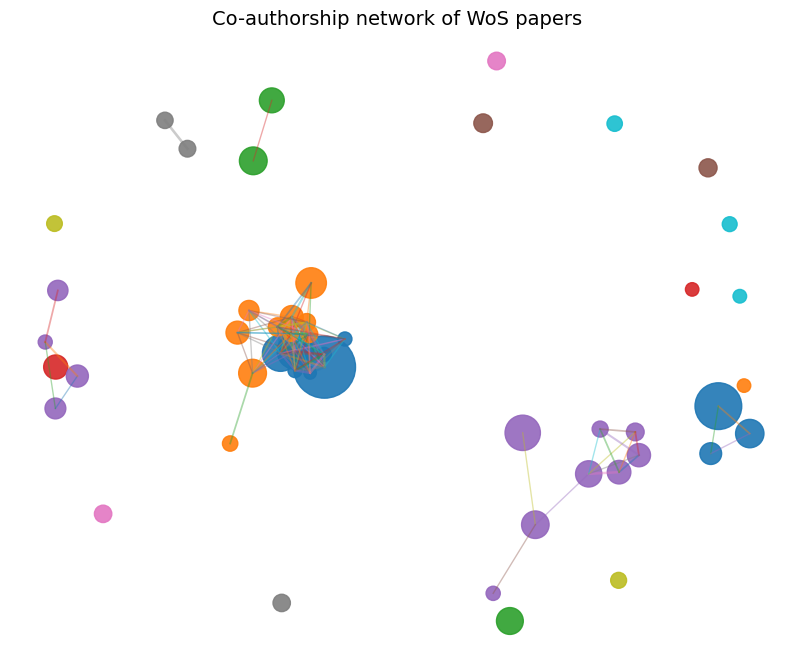

In [7]:
# ============================================================
# Step 5: 可視化
#   - networkx + matplotlib で描画
#   - クラスタごとに色分け
#   - ノードサイズ = log10(times_cited) でスケーリング（約 50〜300）
#   - mpld3 で HTML 出力（マウスオーバーでタイトル・著者・年）
#   - GEXF 出力
# ============================================================

# レイアウト
pos = nx.spring_layout(G, seed=42, k=0.4)

# クラスタごとに色を割り当て
clusters = sorted(set(partition.values()))
cluster_to_color = {c: i for i, c in enumerate(clusters)}

node_x = []
node_y = []
node_sizes = []
node_colors = []
labels = []

# （※この行はループの前に置いてください。変数名は変えていません）
max_times_cited = max([
    int(G.nodes[m].get("times_cited", 0) or 0)
    for m in pos.keys()
])

MAX_SIZE = 2000  # ★ グラフ全体での最大ノードサイズ（調整可）

# ループ開始
for n in pos.keys():
    x, y = pos[n]
    node_x.append(x)
    node_y.append(y)

    times_cited = G.nodes[n].get("times_cited", 0)
    try:
        times_cited = int(times_cited)
    except:
        times_cited = 0

    if max_times_cited > 0:
        size = (times_cited / max_times_cited) * MAX_SIZE
    else:
        size = 50

    # 小さすぎる node を見えるように固定
    if size < 50:
        size = 50

    node_sizes.append(size)

    c = partition.get(n, 0)
    node_colors.append(cluster_to_color.get(c, 0))

    title = G.nodes[n].get("title", "") or ""
    year = G.nodes[n].get("year", "")
    authors = G.nodes[n].get("authors", [])
    auth_str = ", ".join(authors[:3])
    if len(authors) > 3:
        auth_str += f" et al."
    tooltip_text = f"{title[:80]}...\n({year}) {auth_str}"
    labels.append(tooltip_text)



fig, ax = plt.subplots(figsize=(10, 8))

# エッジ描画（weight に応じて太さ変更）
for u, v, data in G.edges(data=True):
    w = data.get("weight", 1)
    ax.plot(
        [pos[u][0], pos[v][0]],
        [pos[u][1], pos[v][1]],
        linewidth=0.5 + 0.7 * np.log1p(w),
        alpha=0.4,
    )

scatter = ax.scatter(
    node_x,
    node_y,
    s=node_sizes,
    c=node_colors,
    cmap="tab10",
    alpha=0.9,
)

ax.set_axis_off()
ax.set_title("Co-authorship network of WoS papers", fontsize=14)

# mpld3 のツールチップ
tooltip = mpld3.plugins.PointLabelTooltip(scatter, labels=labels)
mpld3.plugins.connect(fig, tooltip)

html_str = mpld3.fig_to_html(fig)

html_file = "wos_coauthor_network.html"
with open(html_file, "w", encoding="utf-8") as f:
    f.write(html_str)

print(f"\nInteractive HTML saved to: {html_file}")

# ---- GEXF 出力前に list 属性を文字列化（エラー対策）----
for n in G.nodes:
    authors_attr = G.nodes[n].get("authors")
    if isinstance(authors_attr, list):
        G.nodes[n]["authors"] = "; ".join(authors_attr)

for u, v, d in G.edges(data=True):
    common_attr = d.get("common_authors")
    if isinstance(common_attr, list):
        d["common_authors"] = "; ".join(common_attr)

# GEXF 出力（Gephi 用）
gexf_file = "wos_coauthor_network.gexf"
nx.write_gexf(G, gexf_file)
print(f"GEXF file saved to: {gexf_file}")


In [8]:
# ============================================================
# Step 6 可視化（pyvis インタラクティブバージョン）
# ============================================================

#from pyvis.network import Network

# pyvis ネットワーク生成（高さ・幅など任意）
net = Network(
    height="900px",
    width="100%",
    bgcolor="#FFFFFF",
    font_color="black",
    notebook=False
)

# 物理エンジンをオン
net.force_atlas_2based()

# ---- レイアウト：位置計算（pyvis 用に spring_layout を使う）----
pos = nx.spring_layout(G, seed=42, k=0.4)

# ---- クラスタごとの色 ----
clusters = sorted(set(partition.values()))
cluster_to_color = {c: i for i, c in enumerate(clusters)}

# ---- times_cited の最大値（既存コードと同じ）----
max_times_cited = max([
    int(G.nodes[m].get("times_cited", 0) or 0)
    for m in pos.keys()
])

MAX_SIZE = 80   # pyvis の node size 推奨値（調整可能）

# ---- ノード追加 ----
for n in pos.keys():

    x, y = pos[n]
    px = float(x) * 1000
    py = float(y) * 1000

    times_cited = G.nodes[n].get("times_cited", 0)
    try:
        times_cited = int(times_cited)
    except:
        times_cited = 0

    if max_times_cited > 0:
        size = (times_cited / max_times_cited) * MAX_SIZE
    else:
        size = 10

    if size < 10:
        size = 10

    c = partition.get(n, 0)

    # ★ クラスタ色（固定パレット）
    color_palette = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
    ]
    color = color_palette[c % len(color_palette)]

    title = G.nodes[n].get("title", "") or ""
    year = G.nodes[n].get("year", "")
    authors = G.nodes[n].get("authors", [])
    auth_str = ", ".join(authors[:3])
    if len(authors) > 3:
        auth_str += " et al."

    tooltip = f"<b>{title}</b><br>{year}<br>{auth_str}<br>Times cited: {times_cited}"

    url = G.nodes[n].get("url", None)

    net.add_node(
        n,
        label="",
        title=tooltip,
        size=size,
        color=color,
        x=px,
        y=py,
        physics=False,
        shape="dot",
        url=url
    )


# ---- エッジ追加 ----
for u, v, data in G.edges(data=True):
    w = data.get("weight", 1)
    net.add_edge(
        u, v,
        value=w,
        title=f"co-authored {w} times",
        color="#888888"
    )

# ---- pvis版HTML 出力 ----
pyvis_html_file = "wos_coauthor_network_pyvis.html"
net.write_html(pyvis_html_file)
print(f"pyvis HTML saved to: {pyvis_html_file}")

# ---- GEXF 出力（既存コードそのまま）----
for n in G.nodes:
    authors_attr = G.nodes[n].get("authors")
    if isinstance(authors_attr, list):
        G.nodes[n]["authors"] = "; ".join(authors_attr)

for u, v, d in G.edges(data=True):
    common_attr = d.get("common_authors")
    if isinstance(common_attr, list):
        d["common_authors"] = "; ".join(common_attr)

gexf_file = "wos_coauthor_network.gexf"
nx.write_gexf(G, gexf_file)
print(f"GEXF file saved to: {gexf_file}")



pyvis HTML saved to: wos_coauthor_network_pyvis.html
GEXF file saved to: wos_coauthor_network.gexf


#Step 7:まとめ生成（LLM）

In [9]:
# ============================================================
# Step 6: OpenAI で概要文章を生成
#   - 影響力の強い研究者 10名
#   - 重要論文 Top3
#   - 年代順の研究トレンド
# ============================================================

# 研究者の出現回数 & citation で簡易スコア
author_counter = Counter()
author_citations = defaultdict(int)

for _, row in df.iterrows():
    authors = row["authors"] or []
    tc = int(row["times_cited"]) if pd.notnull(row["times_cited"]) else 0
    for a in authors:
        author_counter[a] += 1
        author_citations[a] += tc

# スコア: 出現回数 + (citation / 50) くらいの重みづけ（適当に）
author_scores = []
for a in author_counter:
    score = author_counter[a] + author_citations[a] / 50.0
    author_scores.append((a, score, author_counter[a], author_citations[a]))

author_scores = sorted(author_scores, key=lambda x: x[1], reverse=True)
top_authors_for_prompt = author_scores[:20]  # プロンプト用には 20 名くらい

# 論文リスト（LLM へのインプット）
paper_lines = []
for idx, row in df.iterrows():
    year = row["year"]
    title = row["title"]
    tc = int(row["times_cited"]) if pd.notnull(row["times_cited"]) else 0
    authors = row["authors"] or []
    auth_str = ", ".join(authors[:3])
    if len(authors) > 3:
        auth_str += " et al."
    line = f"{idx+1}. ({year}) {title} — {auth_str} [citations: {tc}]"
    paper_lines.append(line)

papers_block = "\n".join(paper_lines)

author_block_lines = []
for (name, score, freq, cits) in top_authors_for_prompt:
    author_block_lines.append(
        f"- {name}: appears in {freq} papers, total citations (across retrieved set) = {cits}"
    )
authors_block = "\n".join(author_block_lines)

summary_prompt = f"""
You are an expert scientometrician.

I retrieved up to 50 Web of Science documents for a given topic.
Based on the records below, please provide:

1. A list of the 10 most influential researchers in this topic.
   - Use a mix of (a) how many times they appear and (b) the citation impact of their papers.
   - For each researcher, write 1–2 short sentences about their role or contribution.

2. The Top 3 most important papers in this set.
   - For each paper, give the full title, approximate year, main authors, and a short explanation (2–3 sentences) why it is important.

3. A chronological research trend narrative.
   - Focus primarily on the above search results, and if necessary, supplement any missing information or the author's research achievements with previously acquired information.
   - Describe how the topic evolved over time, in terms of key questions, methods, or findings.
   - Use an academic but readable style.
   - For this issue, output should be in Japanese, but author name in the original languages.

Here is a summary of authors (name, frequency, total citations) computed from the records:
{authors_block}

Here are the individual records (one per paper):
{papers_block}
"""

print("\n=== Asking LLM for textual summary... ===\n")

summary_resp = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are an expert in bibliometrics and research trend analysis."},
        {"role": "user", "content": summary_prompt},
    ],
    max_tokens=1500,
    temperature=0.4,
)

summary_text = summary_resp.choices[0].message.content.strip()
print(summary_text)

# 必要ならファイルにも保存
with open("wos_rag_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("\nSummary saved to: wos_rag_summary.txt")


=== Asking LLM for textual summary... ===

### 1. 影響力のある研究者リスト

1. **He, KM**
   - 彼は深層残差学習の分野での先駆者であり、特に「Deep Residual Learning for Image Recognition」などの重要な論文で知られています。彼の研究は、画像認識の精度を大幅に向上させることに寄与しています。

2. **Ren, SQ**
   - Renは、リアルタイムオブジェクト検出のための「Faster R-CNN」の開発において重要な役割を果たしました。彼の研究は、コンピュータビジョンの分野における多くの応用に影響を与えています。

3. **Sun, J**
   - Sunは、深層学習とコンピュータビジョンの交差点での研究に貢献しており、特にオブジェクト検出や画像分類における新しい手法の開発に注力しています。

4. **Girshick, R**
   - Girshickは、オブジェクト検出の分野での重要な研究者であり、「Fast R-CNN」や「Mask R-CNN」などの革新的な手法を提案しました。彼の研究は、実用的なアプリケーションの開発に大きな影響を与えています。

5. **Krizhevsky, A**
   - 彼は「ImageNet Classification with Deep Convolutional Neural Networks」の著者であり、深層学習のブレークスルーを引き起こした重要な研究者です。彼の手法は、画像認識の精度を飛躍的に向上させました。

6. **Sutskever, I**
   - Sutskeverは、深層学習の基礎を築いた研究者の一人であり、特にニューラルネットワークのトレーニング方法に関する研究で知られています。

7. **Dollár, P**
   - 彼はオブジェクト検出の手法に関する多くの重要な論文に寄与しており、特に「Feature Pyramid Networks」の開発に関与しています。

8. **Zhang, XY**
   - Zhangは、深層学習とコンピュータビジョンの分野での研究において重要な貢献をしており、特に残差ネットワークに関連する研究が評価されています。

9. **